Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
import statsmodels.api as sm



Load Datasets and convert to Datetime

In [3]:

model_data = pd.read_csv('main_data/cbt/C04.csv')
model_data['timestamp'] = pd.to_datetime(model_data['timestamp'] , unit='s')


Temperature Start Core Body temperature


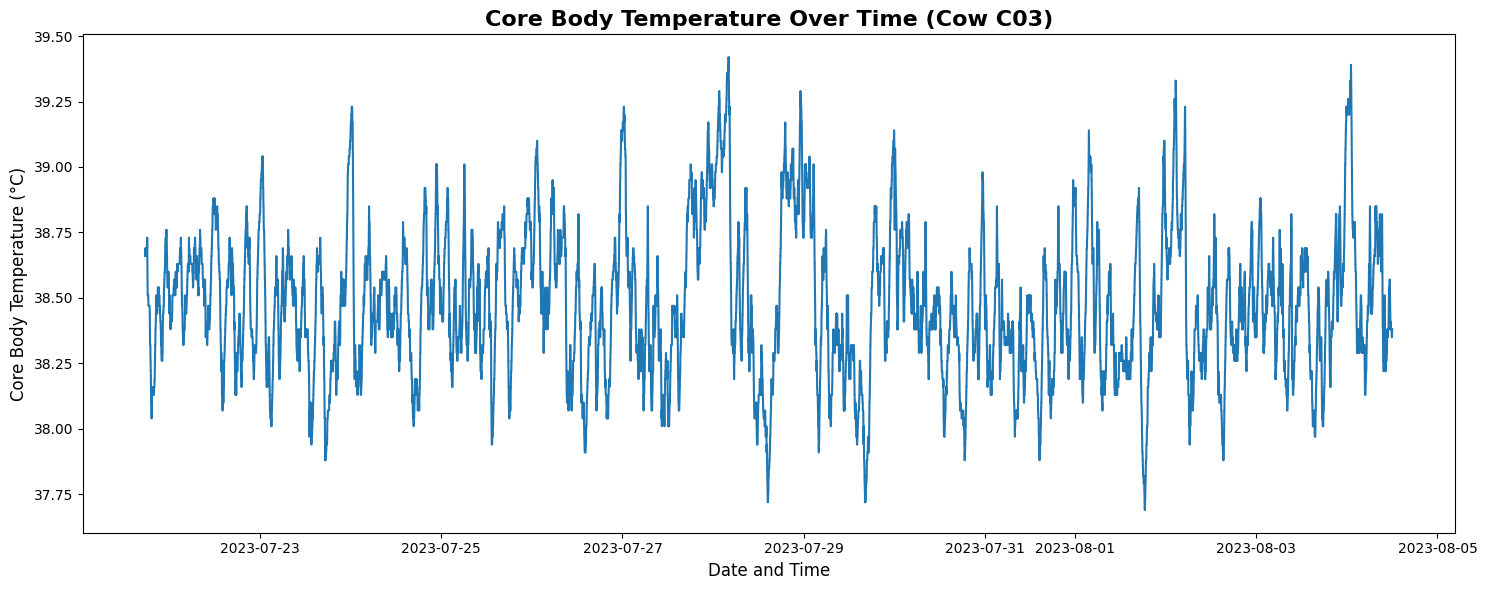

In [4]:


plt.figure(figsize=(15, 6)) 
plt.plot(model_data['timestamp'], model_data['temperature_C'])
plt.title('Core Body Temperature Over Time (Cow C03)', fontsize=16, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Core Body Temperature (°C)', fontsize=12)
plt.tight_layout()
plt.show()

Looking at change Variable and calculating it with a rolling average of 30 min Hier ist rolling window fine aber nur für visualization 


                     temperature_C  temp_change  temp_change_smooth  \
timestamp                                                             
2023-07-21 17:32:00          38.66          NaN                 NaN   
2023-07-21 17:33:00          38.66         0.00               0.000   
2023-07-21 17:34:00          38.69         0.03               0.015   
2023-07-21 17:35:00          38.69         0.00               0.010   
2023-07-21 17:36:00          38.66        -0.03               0.000   

                     temp_centered  velocity_GLLA  temp_GLLA  \
timestamp                                                      
2023-07-21 17:32:00       0.185835       0.002478  38.662213   
2023-07-21 17:33:00       0.185835       0.002372  38.664638   
2023-07-21 17:34:00       0.215835       0.002266  38.666957   
2023-07-21 17:35:00       0.215835       0.002160  38.669170   
2023-07-21 17:36:00       0.185835       0.002054  38.671277   

                     temp_centered_GLLA  temp_change_

C:\Users\Admin\AppData\Local\Temp\ipykernel_15656\3834700427.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  model_data['temp_change_smooth'] = model_data['temp_change'].rolling(window='30T').mean()


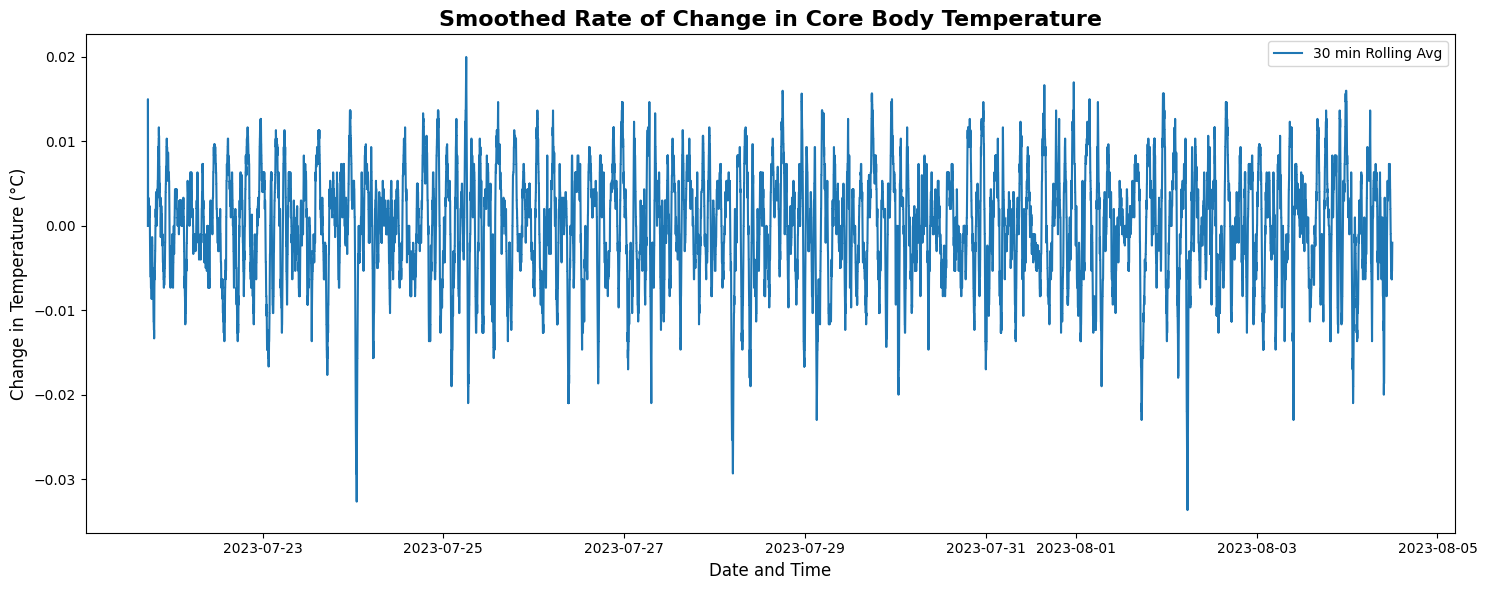

In [17]:

model_data['temp_change'] = model_data['temperature_C'].diff()
model_data = model_data.set_index('timestamp')
model_data['temp_change_smooth'] = model_data['temp_change'].rolling(window='30T').mean()
print(model_data.head())

plt.figure(figsize=(15, 6))
plt.plot(model_data.index, model_data['temp_change_smooth'], label='30 min Rolling Avg')
plt.title('Smoothed Rate of Change in Core Body Temperature', fontsize=16, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Change in Temperature (°C)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

model_data = model_data.reset_index()

Model without rolling average nor GLLA

In [6]:

baseline_data = model_data.dropna(subset=['temperature_C', 'temp_change']).copy()
baseline_data['temp_centered'] = baseline_data['temperature_C'] - baseline_data['temperature_C'].mean()
y_raw = baseline_data['temp_change']
x1_raw = baseline_data['temp_centered']
X_raw = np.column_stack((x1_raw, x1_raw**2))
X_raw = sm.add_constant(X_raw)
res_raw = sm.OLS(y_raw, X_raw).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print(res_raw.summary())

                            OLS Regression Results                            
Dep. Variable:            temp_change   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     9.761
Date:                Thu, 14 May 2026   Prob (F-statistic):           5.79e-05
Time:                        15:33:15   Log-Likelihood:                 51166.
No. Observations:               19830   AIC:                        -1.023e+05
Df Residuals:                   19827   BIC:                        -1.023e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        5.35e-05      0.000      0.299      0.7

Used to split the data every 30 points because of the rolling windo Durbin Watson better now too p values still significant

GLLA Check

In [9]:

from scipy.signal import savgol_filter
window_size = 31  
poly_order = 2    
model_data['velocity_GLLA'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=1)
model_data['temp_GLLA'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=0)
model_data['temp_centered_GLLA'] = model_data['temp_GLLA'] - model_data['temp_GLLA'].mean()
glla_data = model_data.dropna(subset=['velocity_GLLA', 'temp_centered_GLLA']).copy()
glla_data = glla_data.iloc[::30, :]
y_glla = glla_data['velocity_GLLA']
x_glla = glla_data['temp_centered_GLLA']
X_glla = np.column_stack((x_glla, x_glla**2))
X_glla = sm.add_constant(X_glla)
res_glla = sm.OLS(y_glla, X_glla).fit()
print(res_glla.summary())

                            OLS Regression Results                            
Dep. Variable:          velocity_GLLA   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4640
Date:                Thu, 14 May 2026   Prob (F-statistic):              0.629
Time:                        15:33:15   Log-Likelihood:                 2327.8
No. Observations:                 661   AIC:                            -4650.
Df Residuals:                     658   BIC:                            -4636.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001      0.000     -0.433      0.6

Calculated Set Points: [37.47415524 38.58526635]


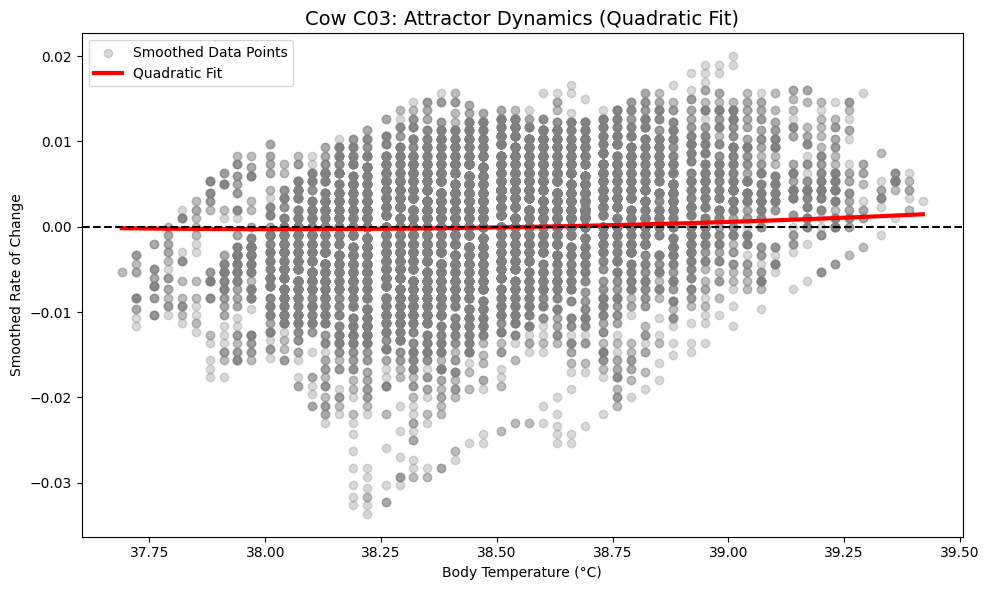

In [19]:
#Coefficents from the analysis before
c, b1, b2 = -0.0001, 0.0008 , 0.0009 
roots = np.roots([b2, b1, c])
real_roots = roots[np.isreal(roots)].real
avg_temp = model_data['temperature_C'].mean()
set_points = real_roots + avg_temp
print(f"Calculated Set Points: {set_points}")
plt.figure(figsize=(10, 6))
plt.scatter(model_data['temperature_C'], model_data['temp_change_smooth'], 
            alpha=0.3, color='gray', label='Smoothed Data Points')
x_range = np.linspace(model_data['temperature_C'].min(), model_data['temperature_C'].max(), 100)
x_centered = x_range - avg_temp
y_pred = c + (b1 * x_centered) + (b2 * x_centered**2)
plt.plot(x_range, y_pred, color='red', linewidth=3, label='Quadratic Fit')
plt.axhline(0, color='black', linestyle='--')
plt.title('Cow C03: Attractor Dynamics (Quadratic Fit)', fontsize=14)
plt.xlabel('Body Temperature (°C)')
plt.ylabel('Smoothed Rate of Change')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()



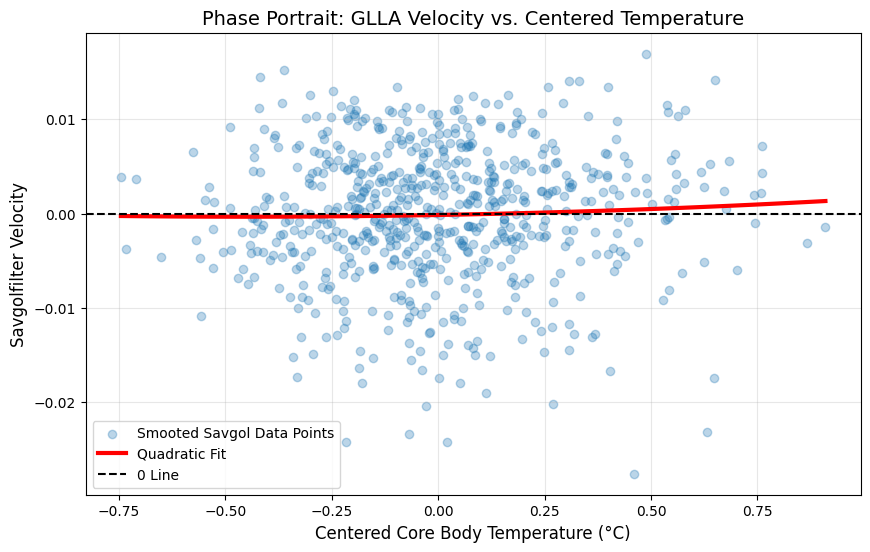

In [10]:

b0, b1, b2 = res_glla.params
plt.figure(figsize=(10, 6))
plt.scatter(glla_data['temp_centered_GLLA'], glla_data['velocity_GLLA'], alpha=0.3, label='Smooted Savgol Data Points')
x_vals = np.linspace(glla_data['temp_centered_GLLA'].min(), glla_data['temp_centered_GLLA'].max(), 100)
y_vals = b0 + b1 * x_vals + b2 * (x_vals**2)
plt.plot(x_vals, y_vals, color='red', linewidth=3, label='Quadratic Fit')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='0 Line')
plt.title('Phase Portrait: GLLA Velocity vs. Centered Temperature', fontsize=14)
plt.xlabel('Centered Core Body Temperature (°C)', fontsize=12)
plt.ylabel('Savgolfilter Velocity', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Calculate the raw rate of change (first derivative approximation)
# Assuming your data is evenly spaced in time.
model_data['temp_change_raw'] = model_data['temperature_C'].diff()

# 2. Clean data and center the temperature
model_data = model_data.dropna(subset=['temperature_C', 'temp_change_raw']).copy()
avg_temp = model_data['temperature_C'].mean()
model_data['temp_centered'] = model_data['temperature_C'] - avg_temp

# 3. Define variables for OLS
y_raw = model_data['temp_change_raw']
x1 = model_data['temp_centered']

# 4. Build the design matrix (c + b1*x + b2*x^2)
X = np.column_stack((x1, x1**2))
X = sm.add_constant(X)

# 5. Fit the model using Newey-West (HAC) standard errors
res_raw = sm.OLS(y_raw, X).fit(cov_type='HAC', cov_kwds={'maxlags': 30})

print("--- OLS Results: Raw Differences ---")
print(res_raw.summary())

--- OLS Results: Raw Differences ---
                            OLS Regression Results                            
Dep. Variable:        temp_change_raw   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.427
Date:                Thu, 14 May 2026   Prob (F-statistic):             0.0325
Time:                        15:33:15   Log-Likelihood:                 51163.
No. Observations:               19829   AIC:                        -1.023e+05
Df Residuals:                   19826   BIC:                        -1.023e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.3

In [15]:
from scipy.signal import savgol_filter

# 1. Apply GLLA to extract the first derivative (rate of change)
# window_length: The size of your embedding window (must be an odd number). 
#                Adjust this based on your sampling rate (e.g., 11 or 21).
# polyorder: 2 means we fit a local quadratic curve.
# deriv: 1 means we are extracting the velocity (first derivative).
model_data['temp_change_glla'] = savgol_filter(
    model_data['temperature_C'], 
    window_length=11, 
    polyorder=2,      
    deriv=1           
)

# 2. Define the new dependent variable
# (We reuse the 'X' design matrix and 'temp_centered' from Method 1)
y_glla = model_data['temp_change_glla']

# 3. Fit the model using Newey-West (HAC) standard errors
res_glla = sm.OLS(y_glla, X).fit(cov_type='HAC', cov_kwds={'maxlags': 30})

print("\n--- OLS Results: GLLA Extracted Derivatives ---")
print(res_glla.summary())


--- OLS Results: GLLA Extracted Derivatives ---
                            OLS Regression Results                            
Dep. Variable:       temp_change_glla   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.002334
Date:                Thu, 14 May 2026   Prob (F-statistic):              0.998
Time:                        15:44:08   Log-Likelihood:                 63677.
No. Observations:               19829   AIC:                        -1.273e+05
Df Residuals:                   19826   BIC:                        -1.273e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con